#### K Neighbors Regressor

K-Neighbors Regressor is a superised machine learning technique taht is used for regression problem statements.

The output of the problem statement must be continuous in nature.

#### Algorithm :---

(i.)    Find out n number of neighbors with respect to the test data.

(ii.)   Find out the distance of each neighbors with respect to the test data through euclidean/ manhattan etc.

(iii.)  Compute the average of all the distances with respect to the test data.


#### Step 1:    Import all the necessary libraries

In [154]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets            import   fetch_california_housing
from    sklearn.model_selection     import   train_test_split, GridSearchCV,  KFold
from    sklearn.preprocessing       import   StandardScaler
from    sklearn.neighbors           import   KNeighborsRegressor
from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from    sklearn.pipeline            import   Pipeline

#### Step 2:    Load the dataset

In [155]:
#### extract the data

data = fetch_california_housing()


data.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [156]:
#### extract the data

data = fetch_california_housing()

#### Constuct the dataframe from the data

df = pd.DataFrame(data.data, columns=data.feature_names)


#### Add the target to the dataset

df['HousePrice'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### OBSERVATIONS:

1.  The above dataset explains about the details of the California Housing.

2.  The independent features of the dataset are as follows :----

        (a.)    HouseAge    ===================>     Age of the House (Duration period of the house)

        (b.)    AveRooms    ===================>     Average rooms of the house per sqft

        (c.)    AveBedrms   ===================>     Average bed rooms of the house per sqft

        (d.)    Population  ===================>     Total population living in the houses

        (e.)    AveOccup    ==================>      Average Occupation of the population living in the house per sqft

        (f.)    Latitude    ====================>    Latitude of the house

        (g.)    Longitude   ====================>    Longitude of the house

        (h.)    MedInc      =====================>   Median Income of the area


3.  The dependent feature of the dataset is House Price . It states the price of the house.

#### Step 3:    Perform the Data Exploration

In [157]:
#### get the top five rows of the dataset

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [158]:
#### get the bottom five rows of the dataset

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [159]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 20640


In [160]:
#### shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (20640, 9)


In [161]:
#### get the columns used in the dataset

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')

In [162]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### OBSERVATIONS:

1.  All the features of the dataset are floating point in nature.

In [163]:
#### get the descriptive summary statistics about all the columns used in the dataset

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### OBSERVATIONS:

1.  It provides us with the descriptive summary statistics about each column in the dataset.

In [164]:
#### get the correlation for each column used in the dataset

df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


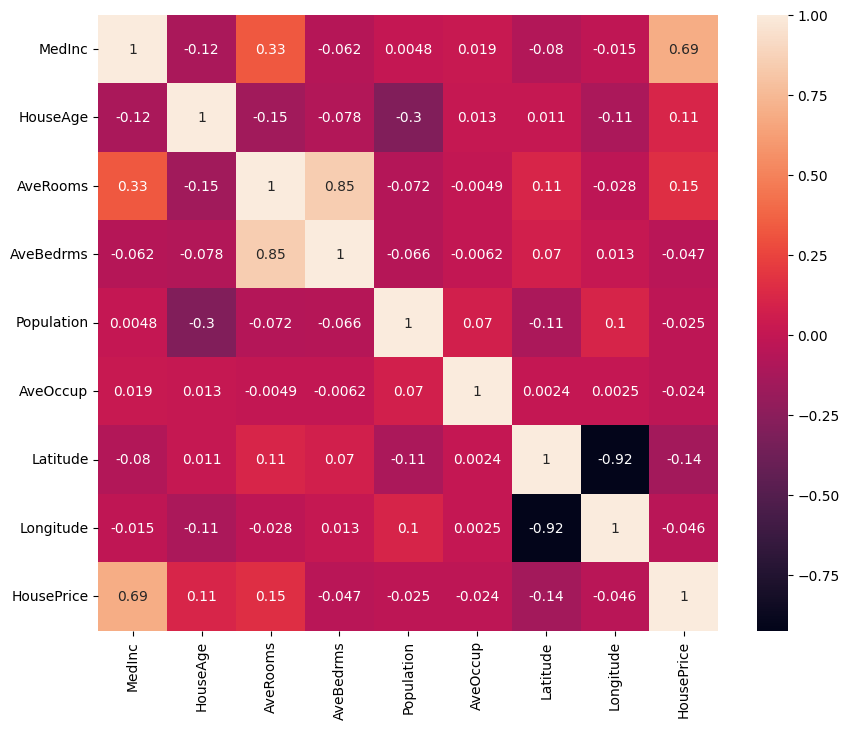

In [165]:
#### get the graphical representation for each column used in the dataset
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

#### OBSERVATIONS:

1.  The above graph explains about the graphical representation between each column used in the dataset.

#### Step 4:    Perform Data Cleaning and Feature Engineering

In [166]:
#### To check for the NULL Values used in the dataset

df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values used in the dataset.

In [167]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [168]:
#### Assign the column names to their proper positions

df = df[["HouseAge", "AveRooms","AveBedrms","Population","AveOccup","Latitude",	"Longitude","MedInc","HousePrice"]]

In [169]:
df.head()

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc,HousePrice
0,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,8.3252,4.526
1,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,8.3014,3.585
2,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,7.2574,3.521
3,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,5.6431,3.413
4,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.8462,3.422


#### OBSERVATIONS:

1.  All the column names have been assigned in their proper positions in the dataset.

#### Step 5:    Divide the dataset into independent and dependent features

In [170]:
#### independent features

X = df.drop(columns="HousePrice",axis=1)

print(X)

       HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0          41.0  6.984127   1.023810       322.0  2.555556     37.88   
1          21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2          52.0  8.288136   1.073446       496.0  2.802260     37.85   
3          52.0  5.817352   1.073059       558.0  2.547945     37.85   
4          52.0  6.281853   1.081081       565.0  2.181467     37.85   
...         ...       ...        ...         ...       ...       ...   
20635      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedInc  
0        -122.23  8.3252  
1        -122.22  8.3014  
2        -122.24  7.2574  
3        -122.25  5.6431  


In [171]:
#### dependent feature

Y = df["HousePrice"]

print(Y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: HousePrice, Length: 20640, dtype: float64


#### Step 6:    Divide the independent and dependent features into training and testing data

In [172]:
from  sklearn.model_selection   import  train_test_split

X_train,X_test,Y_train,Y_test  = train_test_split(X,Y,test_size=0.2,random_state=42)

In [173]:
X_train

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc
14196,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,3.2596
8267,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.8125
17445,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,4.1563
14265,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,1.9425
2271,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,3.5542
...,...,...,...,...,...,...,...,...
11284,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96,6.3700
11964,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43,3.0500
5390,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38,2.9344
860,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96,5.7192


In [174]:
X_test

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc
20046,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,1.6812
3024,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,2.5313
15663,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,3.4801
20484,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,5.7376
9814,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,3.7250
...,...,...,...,...,...,...,...,...
15362,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22,4.6050
16623,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83,2.7266
18086,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05,9.2298
2144,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76,2.7850


In [175]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (16512, 8)
Shape of the input testing  data is: (4128, 8)


In [176]:
Y_train

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: HousePrice, Length: 16512, dtype: float64

In [177]:
Y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: HousePrice, Length: 4128, dtype: float64

In [178]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (16512,)
Shape of the output testing  data is: (4128,)


#### Step 7: Perform Feature Scaling on the inputs

In [179]:
from  sklearn.preprocessing     import    StandardScaler

#### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [180]:
X_train_scaled

array([[ 0.34849025, -0.17491646, -0.20836543, ..., -1.3728112 ,
         1.27258656, -0.326196  ],
       [ 1.61811813, -0.40283542, -0.12853018, ..., -0.87669601,
         0.70916212, -0.03584338],
       [-1.95271028,  0.08821601, -0.25753771, ..., -0.46014647,
        -0.44760309,  0.14470145],
       ...,
       [ 0.58654547, -0.60675918, -0.03921583, ..., -0.75500738,
         0.59946887, -0.49697313],
       [-1.07984112,  0.40217517, -0.06626528, ...,  0.90651045,
        -1.18553953,  0.96545045],
       [ 1.85617335, -0.85144571, -0.08750798, ...,  0.99543676,
        -1.41489815, -0.68544764]])

In [181]:
X_test_scaled = sc.transform(X_test)

In [182]:
X_test_scaled

array([[-0.28632369, -0.52068576, -0.17174603, ...,  0.1951    ,
         0.28534728, -1.15508475],
       [ 0.11043502, -0.16581537,  0.22347203, ..., -0.23549054,
         0.06097472, -0.70865905],
       [ 1.85617335, -0.61076476,  0.20589202, ...,  1.00947776,
        -1.42487026, -0.21040155],
       ...,
       [-0.28632369,  0.75501156, -0.34510886, ...,  0.78014149,
        -1.23041404,  2.80902421],
       [ 0.58654547, -0.06124296, -0.26214684, ...,  0.52740357,
        -0.08860699, -0.57542978],
       [-0.92113763, -0.6058703 , -0.14589658, ..., -0.66608108,
         0.60445493, -0.17259111]])

#### OBSERVATIONS:

1.  All the input features have been transformed in the same scale range between -1 to 1.

#### Step 8: Train the K Neighbors Regressor Model

In [183]:
from sklearn.neighbors import KNeighborsRegressor

#### create an object for KNeighborsRegressor

knnreg = KNeighborsRegressor(
    n_neighbors = 5
)


#### using the object of KNeighborsRegressor, train the model

knnreg.fit(X_train_scaled, Y_train)

KNeighborsRegressor()

#### OBSERVATIONS:

1.  The object for KNeighborsRegressor has been made.

2.  Using the object of KNeighborsRegressor, the KNeighborsRegressor model is trained with training data along with the following parameters :---

    (a.)    n_neighbors = 5 =============>  Total number of neighbors to be considered around the gien test data is 5

#### Step 9: Predict the Model

In [184]:
Y_pred = knnreg.predict(X_test_scaled)

In [185]:
Y_pred

array([0.4988  , 0.7646  , 4.750006, ..., 4.761208, 0.692   , 1.8944  ])

#### Step 10:   Compare the Actual vs Predicted Results

In [186]:
Y_test.ndim

1

In [187]:
Y_pred.ndim

1

In [188]:
df_results = pd.DataFrame({
    "Actual Results"    :   Y_test.values          ,
    "Predicted  Results":   Y_pred                 ,
    "Error"           :   (Y_test.values - Y_pred)
})

In [189]:
df_results

,Actual Results,Predicted Results,Error
0,0.47700,0.498800,-0.021800
1,0.45800,0.764600,-0.306600
2,5.00001,4.750006,0.250004
3,2.18600,2.876600,-0.690600
4,2.78000,2.726200,0.053800
...,...,...,...
4123,2.63300,2.236800,0.396200
4124,2.66800,1.889200,0.778800
4125,5.00001,4.761208,0.238802
4126,0.72300,0.692000,0.031000


#### OBSERVATIONS:

1.  In the above dataframe, we have the actual vs Predicted output  along with the Error (Actual - Predicted) for each and every record.

#### Step 11: Evaluate the Regression Metrics

In [190]:
from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


print("==============================Mean Absolute Error========================================================")

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)



print("==============================Mean Squared Error========================================================")

mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)



print("==============================Root Mean Squared Error========================================================")

rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)


print("==============================R2 Score========================================================")

r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.4461535271317829
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.4324216146043236
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.6575877238850522
==============================R2 Score========================================================
R2 Score of the model is: 0.6700101862970989


#### OBSERVATIONS:

1.  The R2 Score of K Neighbors Regressor Model using californis housing dataset is 0.67.

2.  The R2 Score of the model is high but it can further be improved using Hyper Parameter Tuning with GridSearchCV.

#### Step 12: Predict the House Price of the sample data for California Housing

In [191]:
df.iloc[[0]]

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedInc,HousePrice
0,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,8.3252,4.526


In [192]:
#### Obtain the sample data

sample = X.iloc[[0]]

print(sample)


#### perform the sacling on the sample data

scaled_data = sc.transform(sample)

print(scaled_data)


#### perform the prediction on the scaled data

prediction = knnreg.predict(scaled_data)

print("Predicted House Price of the dataset is:", prediction)

   HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  \
0      41.0  6.984127    1.02381       322.0  2.555556     37.88    -122.23   

   MedInc  
0  8.3252  
[[ 0.98330419  0.64880421 -0.1682248  -0.97135592 -0.04676     1.04692041
  -1.32016306  2.33397811]]
Predicted House Price of the dataset is: [4.756208]


#### Step 13: Plot the Graph with the best line of fit

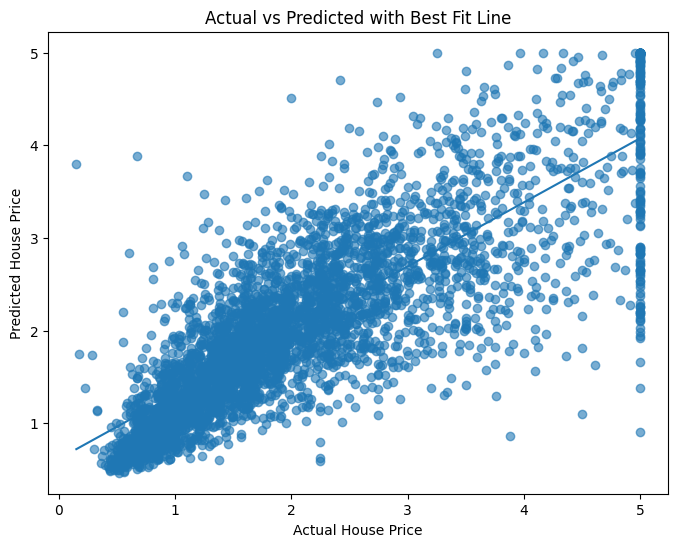

In [193]:
plt.figure(figsize=(8,6))

# Scatter Plot

plt.scatter(
    
    Y_test,
    
    Y_pred,
    
    alpha=0.6
)

# Best Fit Line

m, b = np.polyfit(Y_test, Y_pred, 1)

x = np.sort(Y_test)

plt.plot(
    
    x,
    
    m * x + b
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted with Best Fit Line")

plt.show()

#### Step 14: Perform HyperParameter Tuning using GridSearchCV

In [194]:
#### define the pipeline

from  sklearn.pipeline      import    Pipeline

#### create an object for Pipeline

pipeline    =   Pipeline([
    ("sc"       ,       StandardScaler())               ,
    ("knnreg"   ,       KNeighborsRegressor())
])

In [195]:
#### define the parame grid

param_grid = {
    "knnreg__n_neighbors"       :       [3,5,7,9]                       ,
    "knnreg__weights"           :       ["uniform","distance"]          ,
    "knnreg__metric"            :       ["euclidean","manhattan"]       ,
    "knnreg__p"                 :       [1,2]
}

In [196]:
#### perform the cross validation

cv  =   KFold(n_splits = 5, shuffle = True, random_state = 42)

In [197]:
#### create the object of GridSearchCV

grid = GridSearchCV(
    pipeline                                                            ,
    param_grid                  =           param_grid                  ,
    cv                          =               cv                      ,
    scoring                     =               'r2'                    ,
    n_jobs                      =               -1
)

In [198]:
#### Train the GridSearchCV Model

grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('knnreg', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knnreg__metric': ['euclidean', 'manhattan'],
                         'knnreg__n_neighbors': [3, 5, 7, 9],
                         'knnreg__p': [1, 2],
                         'knnreg__weights': ['uniform', 'distance']},
             scoring='r2')

In [199]:
#### Obtain the best parameters and the estimator for the model

best_parameter = grid.best_params_
print("Best Parameters of the model is:", best_parameter)


best_estimator = grid.best_estimator_
print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'knnreg__metric': 'manhattan', 'knnreg__n_neighbors': 9, 'knnreg__p': 1, 'knnreg__weights': 'distance'}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('knnreg',
                 KNeighborsRegressor(metric='manhattan', n_neighbors=9, p=1,
                                     weights='distance'))])


In [200]:
#### Predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [201]:
Y_pred_grid

array([0.50997325, 0.93723566, 4.42174044, ..., 4.86349795, 0.71807639,
       2.11121145])

In [202]:
##### Evaluate the Regression Metrics

from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


print("==============================Mean Absolute Error========================================================")

maegrid = mean_absolute_error(Y_test, Y_pred_grid)

print("Mean Absolute Error of the model is:", maegrid)



print("==============================Mean Squared Error========================================================")

msegrid = mean_squared_error(Y_test, Y_pred_grid)

print("Mean Squared Error of the model is:", msegrid)



print("==============================Root Mean Squared Error========================================================")

rmsegrid = root_mean_squared_error(Y_test, Y_pred_grid)

print("Root Mean Squared Error of the model is:", rmsegrid)


print("==============================R2 Score========================================================")

r2grid = r2_score(Y_test, Y_pred_grid)

print("R2 Score of the model is:", r2grid)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.40580195325466495
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.3641506481894662
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.6034489607162036
==============================R2 Score========================================================
R2 Score of the model is: 0.72210916268423


#### OBSERVATIONS:

1.  The R2 Score of K Neighbors Regressor Model using californis housing dataset is 0.72.

2.  The R2 Score of the model has improved rom 0.67 to 0.72 ater performing Hyper Parameter Tuning with GridSearchCV operation.

3.  As the R2 Score of the model has improved, so the model is fine.

#### Step 15: Predict the House Price of the sample data ater performing Hyper Parameter Tuning with GridSearchCV

In [203]:
#### Obtain the sample data

sample = X.iloc[[0]]

print(sample)


#### perform the prediction on the sample 

prediction = best_estimator.predict(sample)

print("Predicted House Price of the dataset is:", prediction)

   HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  \
0      41.0  6.984127    1.02381       322.0  2.555556     37.88    -122.23   

   MedInc  
0  8.3252  
Predicted House Price of the dataset is: [4.31296844]


#### Step 16:   Plot the graph with the best line of fit after performing tuning with GridSearchCV

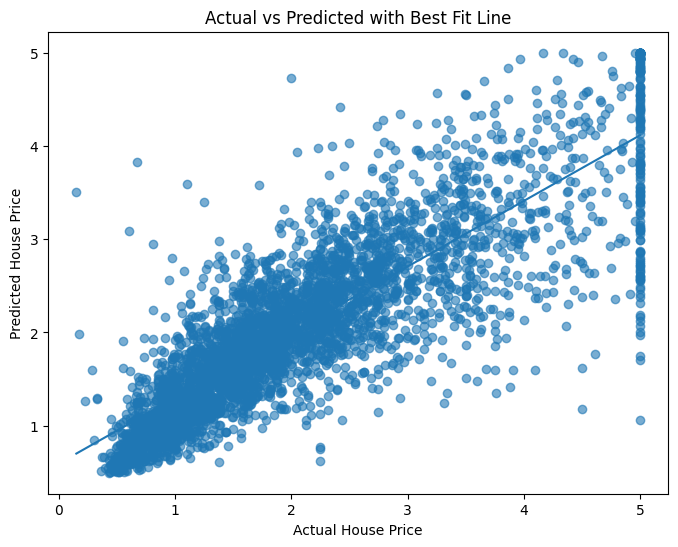

In [204]:
# ============================================
# ACTUAL vs PREDICTED GRAPH
# AFTER HYPER PARAMETER TUNING
# ============================================

plt.figure(figsize=(8,6))

# Scatter Plot

plt.scatter(
    
    Y_test,
    
    Y_pred_grid,
    
    alpha = 0.6
)

# --------------------------------------------
# Best Fit Line
# --------------------------------------------

m, b = np.polyfit(Y_test, Y_pred_grid, 1)

x = np.sort(Y_test)

plt.plot(
    
    x,
    
    m * x + b
)

# --------------------------------------------
# Labels
# --------------------------------------------

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted with Best Fit Line")

plt.show()